In [ ]:
# CELL 1 — Import all libraries (run this first, always)
import pandas as pd          # data loading and manipulation
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # all graphs and charts
import seaborn as sns         # heatmaps (confusion matrix)
import hashlib, csv           # blockchain simulation
from datetime import datetime  # timestamps for audit log

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve, auc
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample

# Chart styling — applies to all figures
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
COLORS = {
    'blue':   '#1F3864',
    'red':    '#C62828',
    'green':  '#2E7D32',
    'gold':   '#C9A84C',
    'orange': '#E65100',
    'teal':   '#00695C',
    'purple': '#6A1B9A',
}
print("✓ Environment ready. Language: Python 3 | Platform: Google Colab")

✓ Environment ready. Language: Python 3 | Platform: Google Colab


In [ ]:
# CELL 2 — Upload and load dataset
from google.colab import files
files.upload()  # click "Choose File" → select credit_scoring_dataset_1000.csv

df = pd.read_csv('credit_scoring_dataset_1000.csv')

print("=== DATASET OVERVIEW ===")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")
print(f"Missing : {df.isna().sum().sum()}")

print("\n=== COLUMN TYPES ===")
print(df.dtypes.to_string())

print("\n=== FIRST 5 ROWS ===")
print(df.head().to_string())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe().round(2).to_string())

print("\n=== CLASS DISTRIBUTION (creditworthiness) ===")
vc = df['creditworthiness'].value_counts()
print(f"Good Credit (1) : {vc[1]}  →  {vc[1]/len(df)*100:.1f}%")
print(f"High Risk   (0) : {vc[0]}  →  {vc[0]/len(df)*100:.1f}%")

print("\n=== LOAN DECISION COUNTS ===")
print(df['loan_decision'].value_counts())

Saving credit_scoring_dataset_1000.csv to credit_scoring_dataset_1000 (2).csv
=== DATASET OVERVIEW ===
Rows    : 1,000
Columns : 13
Missing : 0

=== COLUMN TYPES ===
business_age               float64
monthly_revenue            float64
loan_amount                  int64
repayment_status             int64
digital_payment              int64
business_sector             object
creditworthiness             int64
reputation_score             int64
revenue_stability_score    float64
digital_trust_flag           int64
credit_score               float64
loan_decision               object
loan_amount_usd              int64

=== FIRST 5 ROWS ===
   business_age  monthly_revenue  loan_amount  repayment_status  digital_payment business_sector  creditworthiness  reputation_score  revenue_stability_score  digital_trust_flag  credit_score loan_decision  loan_amount_usd
0           8.1           9375.0        50000                -1                0        Services                 1               100  

In [ ]:
# CELL 3 — Data preprocessing (4 steps)
df_clean = df.copy()  # always work on a copy, keep original safe

# STEP 1: Remove exact duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Step 1 — Duplicates removed: {before - len(df_clean)}")

# STEP 2: Drop rows where more than 50% of values are missing
thresh = int(0.5 * df_clean.shape[1])
before2 = len(df_clean)
df_clean.dropna(thresh=thresh, inplace=True)
print(f"Step 2 — Rows dropped (>50% missing): {before2 - len(df_clean)}")

# STEP 3: One-hot encode the business_sector column
# Converts "Retail" / "Services" / "Manufacturing" into 3 binary columns
df_clean = pd.get_dummies(df_clean, columns=['business_sector'], prefix='sector')
sector_cols = [c for c in df_clean.columns if c.startswith('sector_')]
print(f"Step 3 — Encoded columns: {sector_cols}")

# STEP 4: Normalise monthly_revenue and loan_amount to 0–1 range
# Stops large NTD values from dominating the scoring formula
scaler = MinMaxScaler()
df_clean[['monthly_revenue_norm', 'loan_amount_norm']] = scaler.fit_transform(
    df_clean[['monthly_revenue', 'loan_amount']]
)
print(f"Step 4 — Normalisation done")
print(f"\nFinal dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isna().sum().sum()}")

Step 1 — Duplicates removed: 0
Step 2 — Rows dropped (>50% missing): 0
Step 3 — Encoded columns: ['sector_Manufacturing', 'sector_Retail', 'sector_Services']
Step 4 — Normalisation done

Final dataset: 1000 rows, 17 columns
Missing values: 0


In [ ]:
# CELL 4 — Blockchain simulation + experiment setup

# --- IMMUTABILITY: hash the full dataset with SHA-256 ---
# Any change to any value would produce a completely different hash
dataset_hash = hashlib.sha256(
    df_clean.to_csv(index=False).encode()
).hexdigest()
print(f"[Immutability] Dataset SHA-256 hash:\n  {dataset_hash}")

# --- DECENTRALISATION: split data into 3 virtual nodes ---
n = len(df_clean); c = n // 3
nodes = [df_clean.iloc[i*c : (i+1)*c if i<2 else n].copy() for i in range(3)]
print(f"\n[Decentralisation] 3 nodes created: {[len(nd) for nd in nodes]} samples each")

# --- CONSENSUS: majority vote (at least 2 of 3 nodes must agree) ---
# Each node applies slightly different threshold to simulate independent validation
node1 = (df_clean['credit_score'] >= 70).astype(int).values
node2 = (df_clean['credit_score'] >= 68).astype(int).values
node3 = (df_clean['credit_score'] >= 72).astype(int).values
consensus = (np.column_stack([node1, node2, node3]).sum(axis=1) >= 2).astype(int)
print(f"\n[Consensus] Approved: {consensus.sum()} | Denied: {(consensus==0).sum()}")

# --- TRANSPARENCY: write a tamper-evident audit log ---
with open('audit_log.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['id', 'credit_score', 'decision', 'loan_usd', 'timestamp', 'record_hash'])
    for i, row in df.iterrows():
        rec = f"{i},{row['credit_score']},{row['loan_decision']},{row['loan_amount_usd']}"
        w.writerow([i, row['credit_score'], row['loan_decision'], row['loan_amount_usd'],
                    datetime.now().isoformat(), hashlib.sha256(rec.encode()).hexdigest()])
print(f"\n[Transparency] Audit log saved → audit_log.csv")
print(pd.read_csv('audit_log.csv').head(3).to_string(index=False))

# --- EXPERIMENT: define ground truth and predictions ---
y_true     = df['creditworthiness'].values          # actual label (1=good, 0=risk)
y_pred_sys = (df['loan_decision'] == 'Approved').astype(int).values  # system decision

# Baseline = single node, no consensus, with added noise to simulate instability
np.random.seed(42)
noisy_score  = df['credit_score'] + np.random.normal(0, 15, len(df))
y_pred_base  = (noisy_score >= 70).astype(int).values
print(f"\n[Experiment] Ground truth: {y_true.sum()} good credit, {(y_true==0).sum()} high risk")

[Immutability] Dataset SHA-256 hash:
  ab9a3dec0b58adbf9e2363bcbe1619edaa71a7868797c2e744bf924d33446999

[Decentralisation] 3 nodes created: [333, 333, 334] samples each

[Consensus] Approved: 611 | Denied: 389

[Transparency] Audit log saved → audit_log.csv
 id  credit_score    decision  loan_usd                  timestamp                                                      record_hash
  0         67.75 Conditional      2000 2026-04-18T13:09:18.931908 d9f0059d93477cf813d3b894ebb96e5c9064eef6afe01fb2221677b8e7493e8f
  1         28.40    Referred         0 2026-04-18T13:09:18.932027 c551a188dfc17d3e78d826a0809867de16e0fe82217765c20b6c2f98b6970393
  2        100.00    Approved      5000 2026-04-18T13:09:18.932104 5931fc4c869330868fc221296698097ea324552156d8bc2a61788d58e2e7be45

[Experiment] Ground truth: 792 good credit, 208 high risk


In [ ]:
# CELL 5 — All evaluation metrics + tables

def get_metrics(yt, yp, label):
    a = accuracy_score(yt, yp)
    p = precision_score(yt, yp, zero_division=0)
    r = recall_score(yt, yp, zero_division=0)
    f = f1_score(yt, yp, zero_division=0)
    print(f"\n[{label}]")
    print(f"  Accuracy  = {a:.4f}  ({a*100:.2f}%)")
    print(f"  Precision = {p:.4f}  ({p*100:.2f}%)")
    print(f"  Recall    = {r:.4f}  ({r*100:.2f}%)")
    print(f"  F1-Score  = {f:.4f}  ({f*100:.2f}%)")
    return a, p, r, f

acc_s, prec_s, rec_s, f1_s = get_metrics(y_true, y_pred_sys,  "Blockchain Consensus System")
acc_b, prec_b, rec_b, f1_b = get_metrics(y_true, y_pred_base, "Single-Node Baseline")

# Full classification report
print("\n=== FULL CLASSIFICATION REPORT (System) ===")
print(classification_report(y_true, y_pred_sys, target_names=['High Risk', 'Good Credit']))

# TABLE 1: side-by-side comparison
print("=== TABLE 1: SYSTEM vs BASELINE ===")
print(f"{'Metric':<14}{'System':>12}{'Baseline':>12}{'Improvement':>14}")
print("-"*52)
for name, sv, bv in zip(
        ['Accuracy','Precision','Recall','F1-Score'],
        [acc_s,prec_s,rec_s,f1_s], [acc_b,prec_b,rec_b,f1_b]):
    d=sv-bv; sg='+'if d>=0 else ''
    print(f"{name:<14}{sv:>8.4f} ({sv*100:.1f}%){bv:>8.4f} ({bv*100:.1f}%)  {sg}{d*100:.2f}%")

# TABLE 2: Bootstrap 95% confidence intervals
boot = {'Accuracy':[], 'Precision':[], 'Recall':[], 'F1':[]}
for _ in range(1000):
    idx = resample(range(len(y_true)))
    yt, yp = y_true[idx], y_pred_sys[idx]
    boot['Accuracy'].append(accuracy_score(yt,yp))
    boot['Precision'].append(precision_score(yt,yp,zero_division=0))
    boot['Recall'].append(recall_score(yt,yp,zero_division=0))
    boot['F1'].append(f1_score(yt,yp,zero_division=0))
ci = {}
print("\n=== TABLE 2: BOOTSTRAP 95% CONFIDENCE INTERVALS ===")
for k,v in boot.items():
    lo,hi = np.percentile(v,[2.5,97.5])
    ci[k] = (np.mean(v), lo, hi)
    print(f"  {k:<12}: {np.mean(v):.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

# TABLE 3: Loan decision breakdown
print("\n=== TABLE 3: LOAN DECISION DISTRIBUTION ===")
dstat = df.groupby('loan_decision').agg(
    Count=('credit_score','count'),
    Avg_Score=('credit_score','mean'),
    Good_Credit=('creditworthiness','sum')).round(2)
dstat['% of Total']  = (dstat['Count']/len(df)*100).round(1)
dstat['% Good Credit']= (dstat['Good_Credit']/dstat['Count']*100).round(1)
print(dstat.to_string())

good_group = df[df['creditworthiness']==1]
bad_group  = df[df['creditworthiness']==0]


[Blockchain Consensus System]
  Accuracy  = 0.6670  (66.70%)
  Precision = 0.8756  (87.56%)
  Recall    = 0.6755  (67.55%)
  F1-Score  = 0.7627  (76.27%)

[Single-Node Baseline]
  Accuracy  = 0.5530  (55.30%)
  Precision = 0.8402  (84.02%)
  Recall    = 0.5379  (53.79%)
  F1-Score  = 0.6559  (65.59%)

=== FULL CLASSIFICATION REPORT (System) ===
              precision    recall  f1-score   support

   High Risk       0.34      0.63      0.44       208
 Good Credit       0.88      0.68      0.76       792

    accuracy                           0.67      1000
   macro avg       0.61      0.66      0.60      1000
weighted avg       0.76      0.67      0.70      1000

=== TABLE 1: SYSTEM vs BASELINE ===
Metric              System    Baseline   Improvement
----------------------------------------------------
Accuracy        0.6670 (66.7%)  0.5530 (55.3%)  +11.40%
Precision       0.8756 (87.6%)  0.8402 (84.0%)  +3.54%
Recall          0.6755 (67.6%)  0.5379 (53.8%)  +13.76%
F1-Score        

/tmp/ipykernel_10607/856015561.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([good_scores, bad_scores], patch_artist=True,


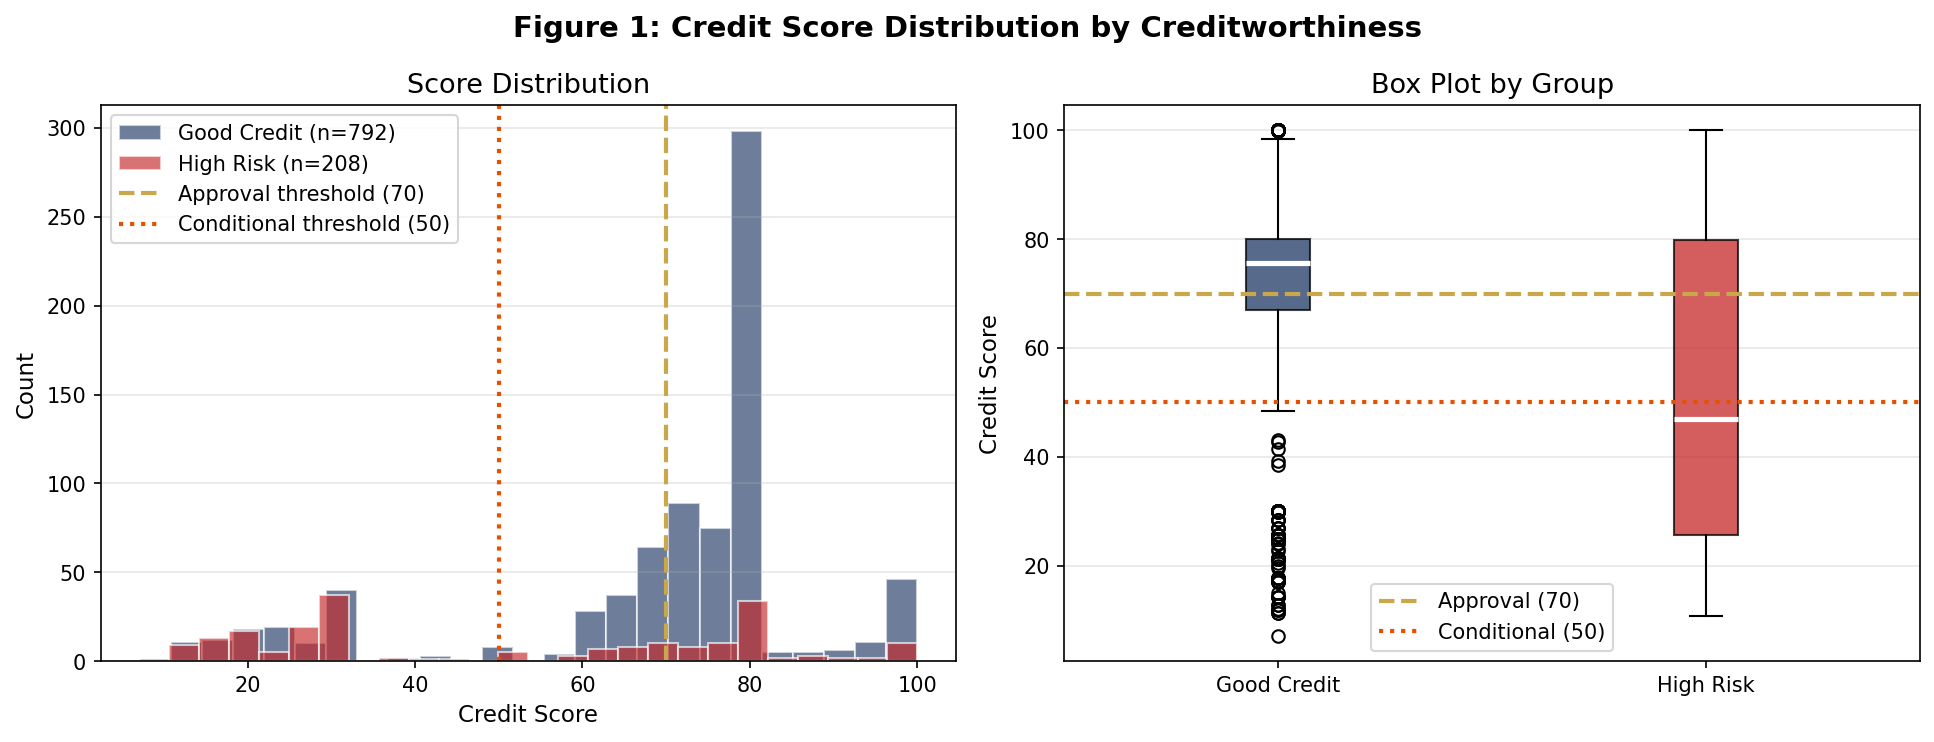

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

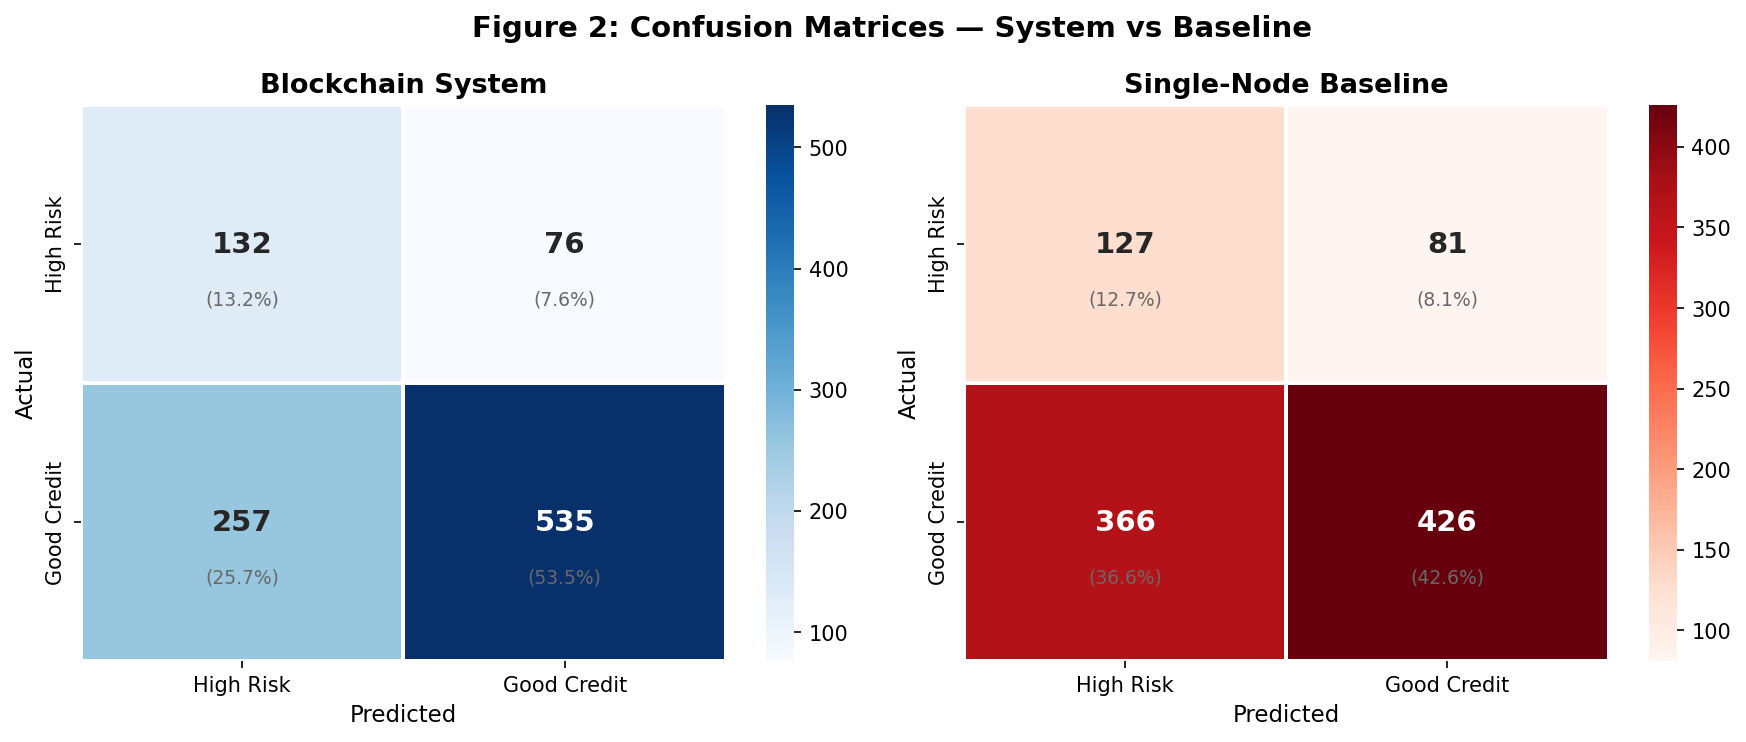

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL 6 — Figure 1: Credit Score Distribution + Figure 2: Confusion Matrices
from google.colab import files

# ── FIGURE 1 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1: Credit Score Distribution by Creditworthiness',
             fontsize=14, fontweight='bold')

good_scores = df[df['creditworthiness']==1]['credit_score']
bad_scores  = df[df['creditworthiness']==0]['credit_score']

axes[0].hist(good_scores, bins=25, color=COLORS['blue'], alpha=0.65,
             label=f'Good Credit (n={len(good_scores)})', edgecolor='white')
axes[0].hist(bad_scores, bins=25, color=COLORS['red'], alpha=0.65,
             label=f'High Risk (n={len(bad_scores)})', edgecolor='white')
axes[0].axvline(70, color=COLORS['gold'], linestyle='--', lw=2, label='Approval threshold (70)')
axes[0].axvline(50, color=COLORS['orange'], linestyle=':', lw=2, label='Conditional threshold (50)')
axes[0].set_xlabel('Credit Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

bp = axes[1].boxplot([good_scores, bad_scores], patch_artist=True,
                     labels=['Good Credit', 'High Risk'],
                     medianprops={'color':'white','linewidth':2.5})
for patch, c in zip(bp['boxes'], [COLORS['blue'], COLORS['red']]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[1].axhline(70, color=COLORS['gold'], linestyle='--', lw=2, label='Approval (70)')
axes[1].axhline(50, color=COLORS['orange'], linestyle=':', lw=2, label='Conditional (50)')
axes[1].set_ylabel('Credit Score'); axes[1].set_title('Box Plot by Group')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig1_score_dist.png')

# ── FIGURE 2 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 2: Confusion Matrices — System vs Baseline',
             fontsize=14, fontweight='bold')
labels = ['High Risk', 'Good Credit']

for ax, yp, title, cmap in zip(axes,
        [y_pred_sys, y_pred_base],
        ['Blockchain System', 'Single-Node Baseline'],
        ['Blues', 'Reds']):
    cm = confusion_matrix(y_true, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels,
                annot_kws={'size':14,'weight':'bold'}, linewidths=1, linecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.72, f'({cm[i,j]/total*100:.1f}%)',
                    ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.savefig('fig2_confusion.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig2_confusion.png')


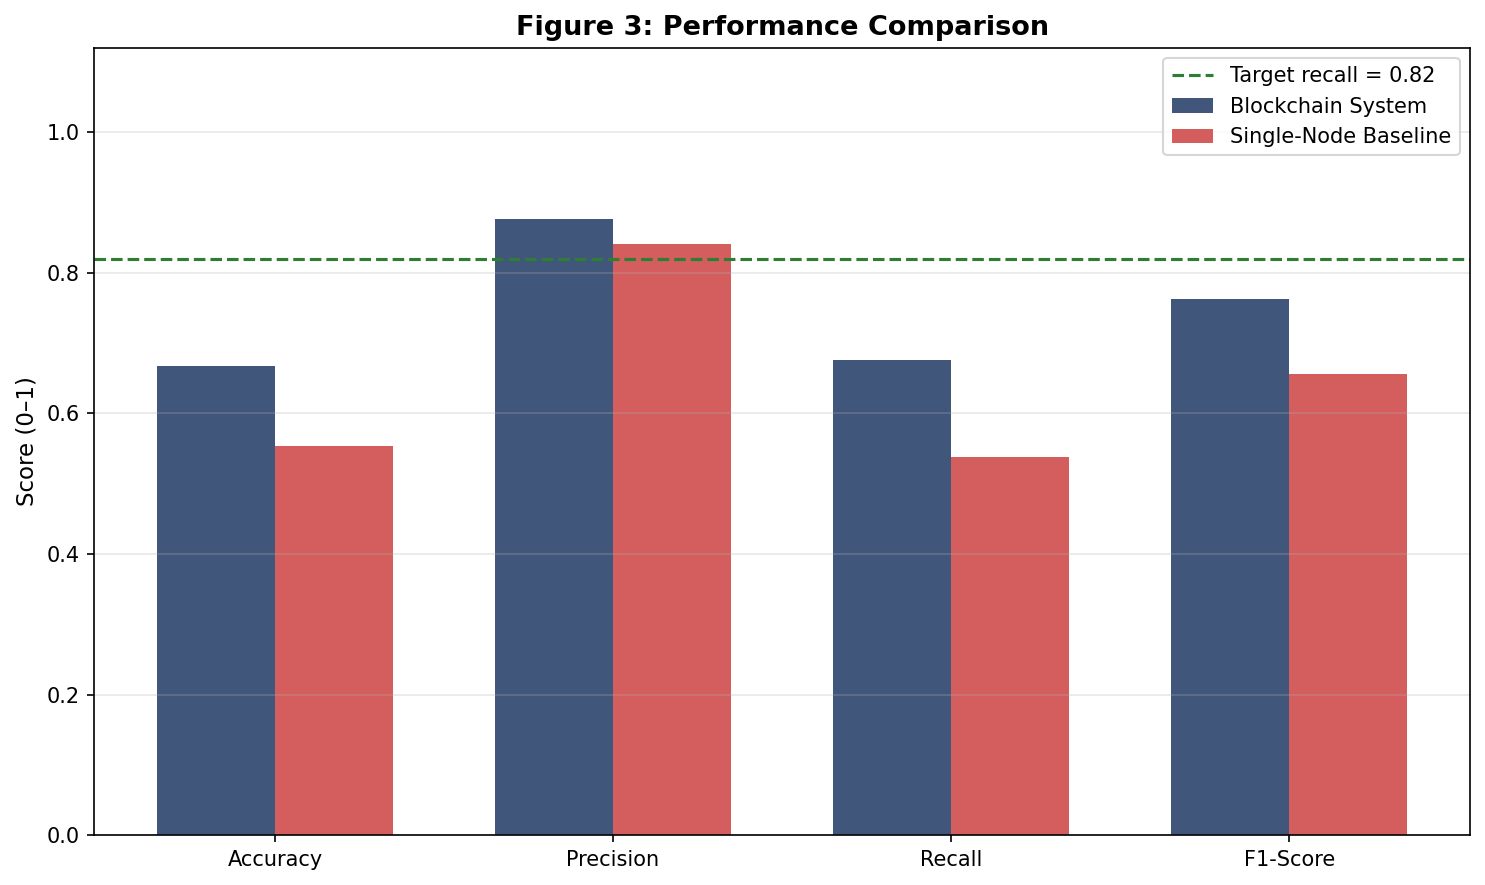

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

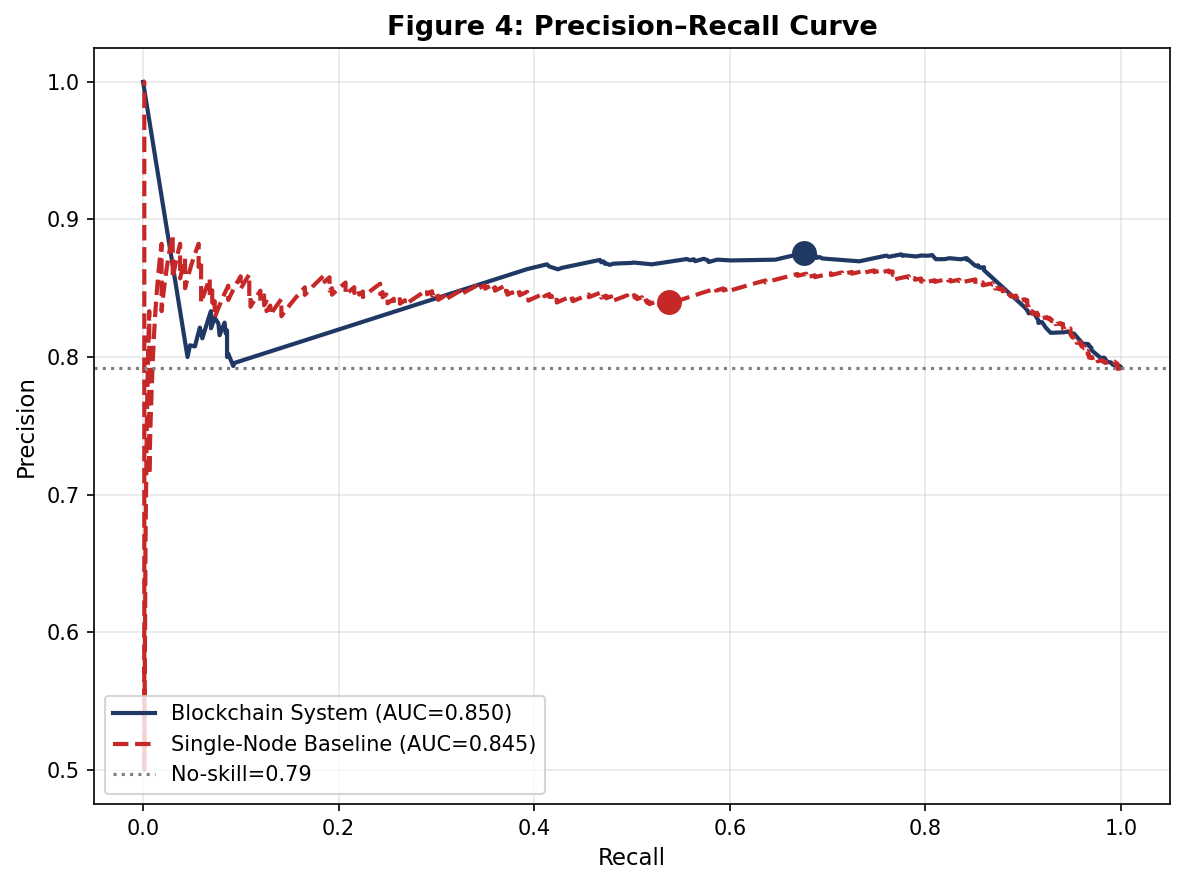

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

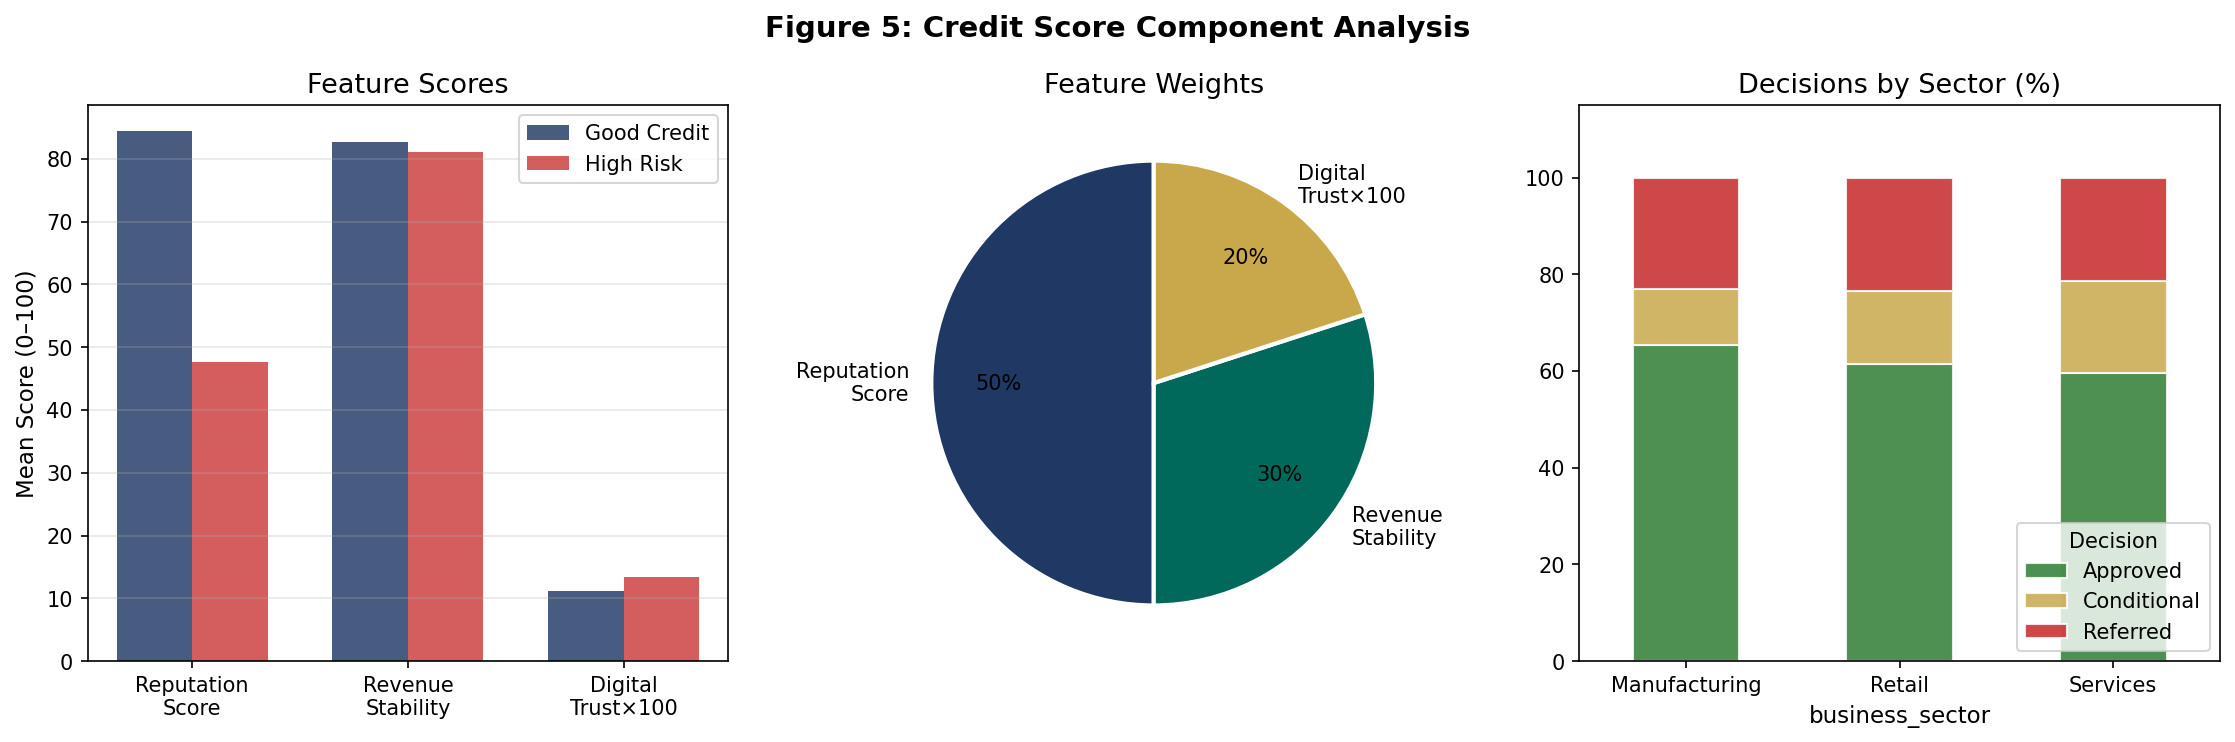

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL 7 — Figures 3–5 (Bar chart, PR curve, Components)
from google.colab import files

# Figure 3: Performance Comparison
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
sys_vals  = [acc_s, prec_s, rec_s, f1_s]
base_vals = [acc_b, prec_b, rec_b, f1_b]
x = np.arange(4); w = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x-w/2, sys_vals,  w, label='Blockchain System',    color=COLORS['blue'], alpha=0.85)
b2 = ax.bar(x+w/2, base_vals, w, label='Single-Node Baseline', color=COLORS['red'],  alpha=0.75)
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score (0–1)')
ax.set_title('Figure 3: Performance Comparison', fontweight='bold')
ax.axhline(0.82, color=COLORS['green'], linestyle='--', lw=1.5, label='Target recall = 0.82')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('fig3_metrics.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig3_metrics.png')

# Figure 4: Precision–Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))
for scores, yp, color, ls, label, r, p in [
        (df['credit_score']/100, y_pred_sys, COLORS['blue'], '-', 'Blockchain System', rec_s, prec_s),
        (noisy_score/100, y_pred_base, COLORS['red'], '--', 'Single-Node Baseline', rec_b, prec_b)]:
    pc, rc, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(rc, pc)
    ax.plot(rc, pc, color=color, lw=2, linestyle=ls, label=f'{label} (AUC={pr_auc:.3f})')
    ax.scatter([r], [p], color=color, s=120, zorder=5)
ax.axhline(y_true.mean(), color='gray', linestyle=':', lw=1.5, label=f'No-skill={y_true.mean():.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Figure 4: Precision–Recall Curve', fontweight='bold')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig4_pr_curve.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig4_pr_curve.png')

# Figure 5: Component Analysis (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 5: Credit Score Component Analysis', fontweight='bold', fontsize=14)

# Panel A
comp_labels = ['Reputation\nScore', 'Revenue\nStability', 'Digital\nTrust×100']
g_means = [good_group['reputation_score'].mean(),
           good_group['revenue_stability_score'].mean(),
           good_group['digital_trust_flag'].mean()*100]
b_means = [bad_group['reputation_score'].mean(),
           bad_group['revenue_stability_score'].mean(),
           bad_group['digital_trust_flag'].mean()*100]
xc = np.arange(3); wc = 0.35
axes[0].bar(xc-wc/2, g_means, wc, color=COLORS['blue'], alpha=0.82, label='Good Credit')
axes[0].bar(xc+wc/2, b_means, wc, color=COLORS['red'],  alpha=0.75, label='High Risk')
axes[0].set_xticks(xc); axes[0].set_xticklabels(comp_labels)
axes[0].set_ylabel('Mean Score (0–100)'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_title('Feature Scores')

# Panel B
axes[1].pie([0.5,0.3,0.2], labels=comp_labels,
            autopct='%1.0f%%', colors=[COLORS['blue'], COLORS['teal'], COLORS['gold']],
            startangle=90, pctdistance=0.7, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Feature Weights')

# Panel C
ds = pd.crosstab(df['business_sector'], df['loan_decision'], normalize='index')*100
ds[['Approved', 'Conditional', 'Referred']].plot(kind='bar', stacked=True, ax=axes[2],
    color=[COLORS['green'], COLORS['gold'], COLORS['red']], alpha=0.85, edgecolor='white')
axes[2].set_title('Decisions by Sector (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_ylim(0,115); axes[2].legend(title='Decision', loc='lower right')
plt.tight_layout(); plt.savefig('fig5_components.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig5_components.png')


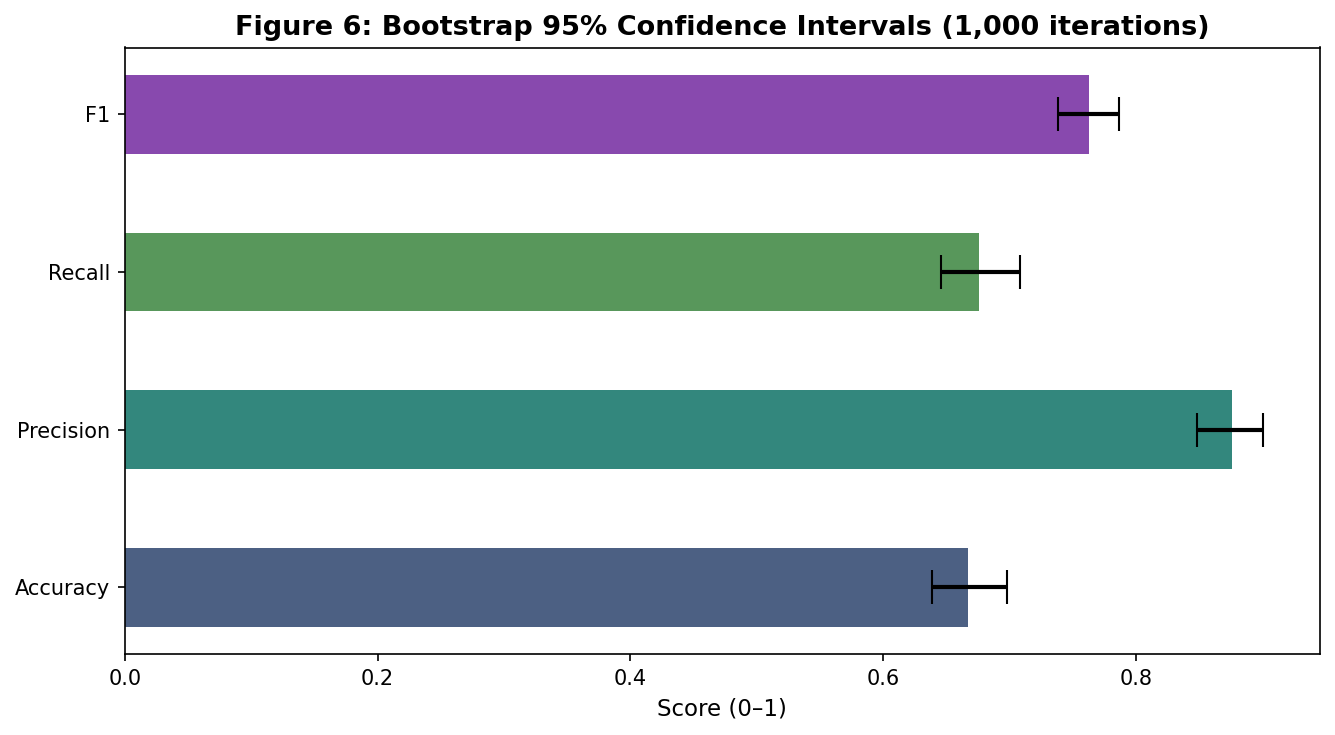

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

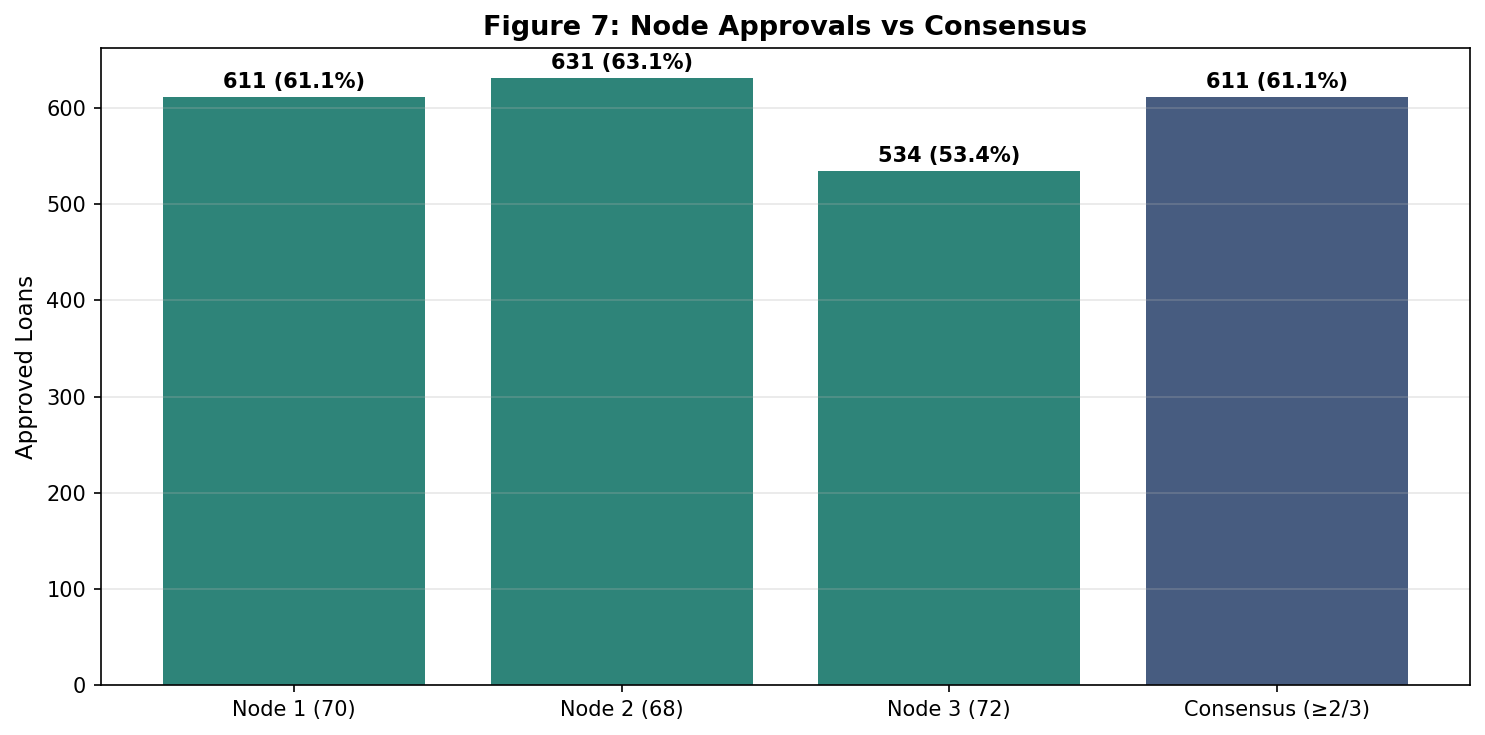

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL 8 — Figure 6 & Figure 7 (Bootstrap CI + Node comparison)
from google.colab import files

# Figure 6: Bootstrap CI
fig, ax = plt.subplots(figsize=(9, 5))
names = list(ci.keys())
means = [ci[m][0] for m in names]
lowers = [ci[m][0]-ci[m][1] for m in names]
uppers = [ci[m][2]-ci[m][0] for m in names]
yp = np.arange(len(names))
ax.barh(yp, means, height=0.5, color=[COLORS['blue'], COLORS['teal'], COLORS['green'], COLORS['purple']], alpha=0.8)
ax.errorbar(means, yp, xerr=[lowers, uppers], fmt='none', color='black', capsize=8, linewidth=2)
ax.set_yticks(yp); ax.set_yticklabels(names); ax.set_xlabel('Score (0–1)')
ax.set_title('Figure 6: Bootstrap 95% Confidence Intervals (1,000 iterations)', fontweight='bold')
plt.tight_layout(); plt.savefig('fig6_ci.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig6_ci.png')

# Figure 7: Node vs Consensus
node_labels = ['Node 1 (70)', 'Node 2 (68)', 'Node 3 (72)', 'Consensus (≥2/3)']
approved_counts = [node1.sum(), node2.sum(), node3.sum(), consensus.sum()]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(node_labels, approved_counts, color=[COLORS['teal']]*3+[COLORS['blue']], alpha=0.82)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{b.get_height()} ({b.get_height()/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Approved Loans'); ax.set_title('Figure 7: Node Approvals vs Consensus', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('fig7_nodes.png', dpi=150, bbox_inches='tight'); plt.show()
files.download('fig7_nodes.png')
